# Attention Visualizer - Autoregressive Transformer

# Preps

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent

sys.path.insert(0, str(PROJECT_ROOT))

print(f"Project root: {PROJECT_ROOT}")

Project root: /Users/zeguru/Projects/AI/tiny-text-transformers


# Imports

In [4]:
import math
import torch
import matplotlib.pyplot as plt

from src.task.config import ModelConfig
from src.task.model import load_model
from src.infra.tokenizer import CharacterTokenizer

# Load resources

In [81]:
corpus = "../data/tiny_shakespear.txt"
checkpoint = "../checkpoints/mh_tiny_text_generator.pt"
shakespear_tokenizer = "../checkpoints/shakespeare_tokenizer.json"

tokenizer_path = Path(shakespear_tokenizer)
data_path = Path(corpus)

tokenizer = CharacterTokenizer.load(tokenizer_path)
text = data_path.read_text(encoding="utf-8",)

text_length = len(text)
print(f"text_legnth : {text_length}")

text_legnth : 1115394


# Load the model for evaluation / inference
### `model.eval()` tells certain PyTorch layers to change their behavior. especially dropout
### Does not

- turn off gradients
- freeze parameters
- change the learned weights
- calculate validation loss
- run the model's evaluation function

NB: thats the job of `with torch.no_grad():`

In [82]:
config = ModelConfig()
config.number_of_heads = 2  #We trained with 2 heads

model = load_model(
    checkpoint_path=checkpoint,
    config=config,
    vocab_size=tokenizer.vocab_size,
    )

model.eval()

At TinyTransformerLM
number of heads:  2
multi head
number of heads:  2
multi head


TinyTransformerLM(
  (input_representation): InputRepresentation(
    (token_embedding): Embedding(
      (embedding): Embedding(67, 64)
    )
    (positional_embedding): PositionalEmbedding(
      (embedding): Embedding(64, 64)
    )
  )
  (transformer): Transformer(
    (blocks): ModuleList(
      (0-1): 2 x TransformerBlock(
        (attention): MultiHeadAttention(
          (query): Linear(in_features=64, out_features=64, bias=False)
          (key): Linear(in_features=64, out_features=64, bias=False)
          (value): Linear(in_features=64, out_features=64, bias=False)
          (output_projection): Linear(in_features=64, out_features=64, bias=True)
        )
        (feed_forward): FeedForward(
          (net): Sequential(
            (0): Linear(in_features=64, out_features=256, bias=True)
            (1): GELU(approximate='none')
            (2): Linear(in_features=256, out_features=64, bias=True)
          )
        )
        (layer_norm_1): LayerNorm((64,), eps=1e-05, elemen

# Pick some text

In [60]:

# prompt_text = "To be or not "
prompt_text = text[1000:1060]

tokens = torch.tensor(
    [tokenizer.encode(prompt_text)],
    dtype=torch.long,
)

# Inspect First Transformer Block (Layer 0)
## Rebuild attention since the blocks are not, yet, configured to return it
## Attention Is All You Need

In [61]:

# --------------------------------------------------
# Get the input to the first attention layer
# --------------------------------------------------

with torch.no_grad():

    x = model.input_representation(tokens)

    attention_module = model.transformer.blocks[0].attention

    Q = attention_module.query(x)
    K = attention_module.key(x)

    B, T, _ = Q.shape
    H = attention_module.number_of_heads
    D = attention_module.head_dim

    Q = Q.view(B, T, H, D).transpose(1, 2)
    K = K.view(B, T, H, D).transpose(1, 2)

    raw_scores = Q @ K.transpose(-2, -1)
    raw_scores = raw_scores / math.sqrt(D)

    mask = attention_module.mask[:T, :T]

    masked_scores = raw_scores.masked_fill(
        mask,
        float("-inf"),
    )

    attention = torch.softmax(masked_scores, dim=-1)



# 1. Heatmap

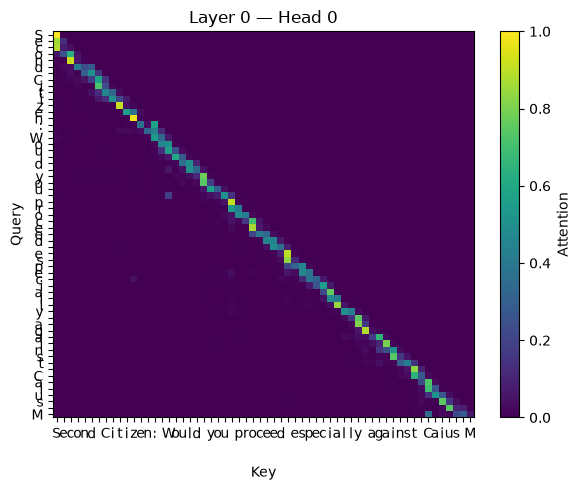

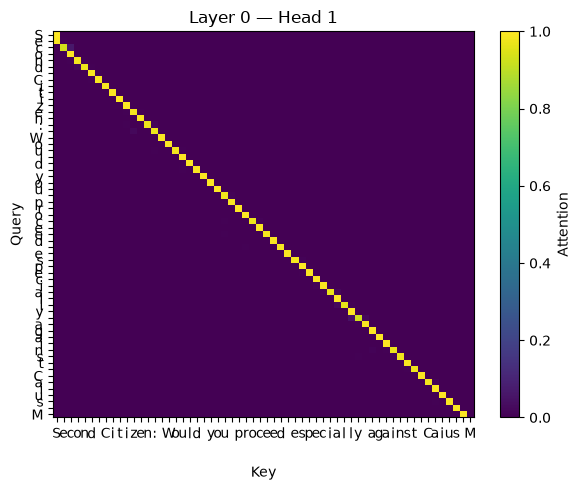

In [62]:

# --------------------------------------------------
# Visualize
# --------------------------------------------------

for head in range(H):

    plt.figure(figsize=(6, 5))

    plt.imshow(
        attention[0, head].cpu().numpy(),
        aspect="auto",
    )

    plt.title(f"Layer 0 — Head {head}")
    plt.xlabel("Key")
    plt.ylabel("Query")

    plt.xticks(
        range(T),
        list(prompt_text),
    )

    plt.yticks(
        range(T),
        list(prompt_text),
    )

    plt.colorbar(label="Attention")

    plt.tight_layout()
    plt.show()

## Take one head

In [73]:
head = 0

raw = raw_scores[0, head].cpu()
probs = attention[0, head].cpu()

print("raw:", raw_scores.shape)
print("masked:", masked_scores.shape)
print("attention:", probs.shape)

raw: torch.Size([1, 2, 60, 60])
masked: torch.Size([1, 2, 60, 60])
attention: torch.Size([60, 60])


## Raw Scores, Masked Scores, Probabilities

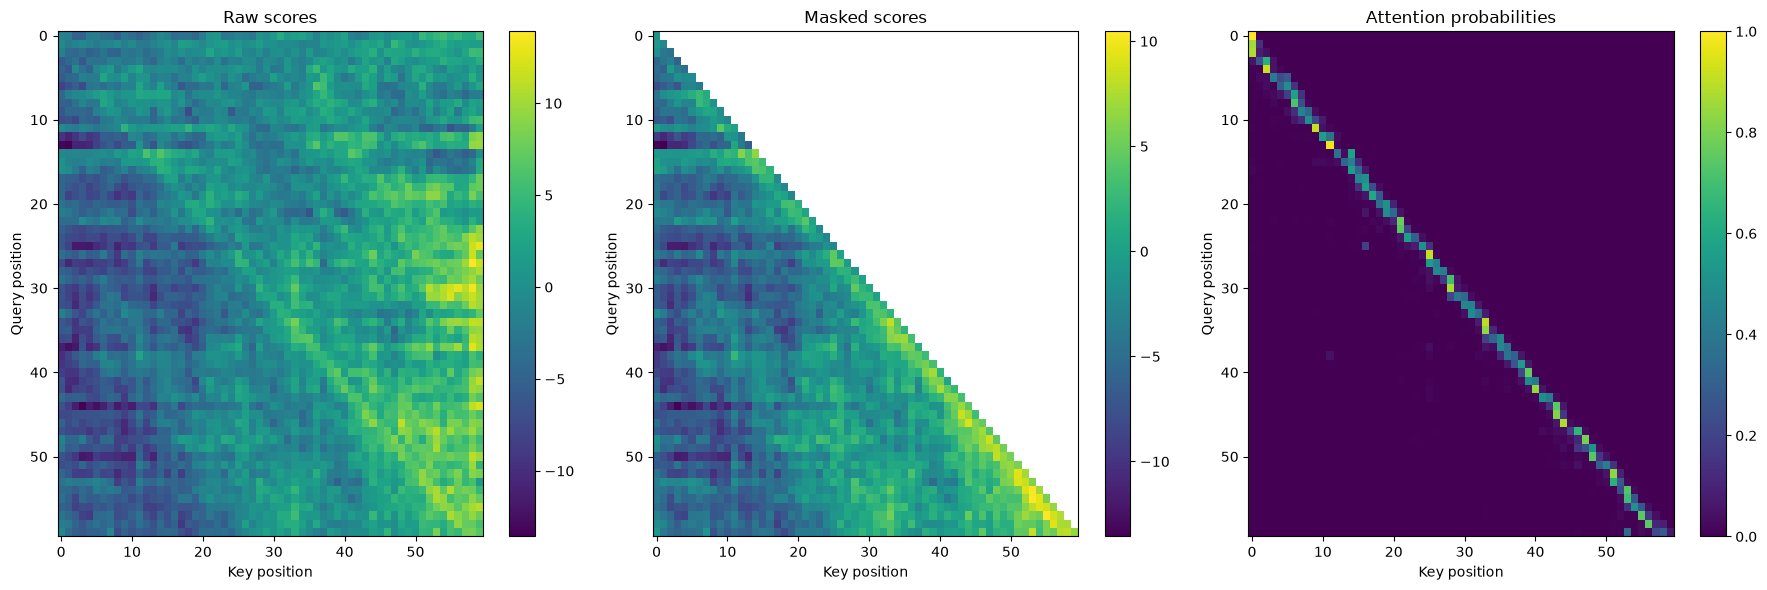

In [74]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

matrices = [
    (raw_scores[0, head], "Raw scores"),
    (masked_scores[0, head], "Masked scores"),
    (attention[0, head], "Attention probabilities"),
]

for ax, (matrix, title) in zip(axes, matrices):
    im = ax.imshow(
        matrix.cpu(),
        aspect="auto",
    )
    ax.set_title(title)
    ax.set_xlabel("Key position")
    ax.set_ylabel("Query position")
    fig.colorbar(im, ax=ax)

plt.tight_layout()
plt.show()

## Attention Distance - useful for character model

In [75]:
positions = torch.arange(T)

# head = 0

distance = (
    attention[0, head]
    * (positions[:, None] - positions[None, :]).abs()
).sum(dim=-1)

## Plot


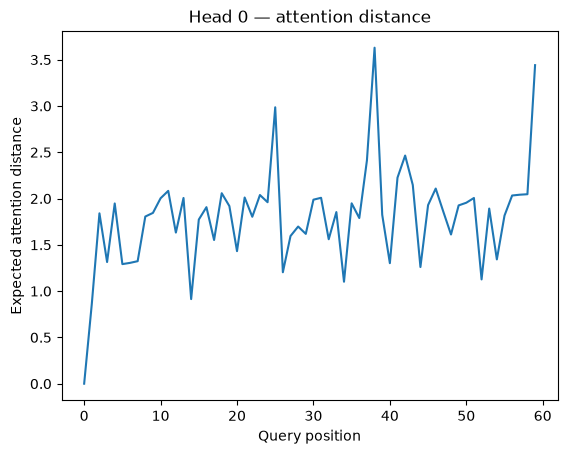

In [76]:
plt.plot(distance.cpu())
plt.xlabel("Query position")
plt.ylabel("Expected attention distance")
plt.title(f"Head {head} — attention distance")
plt.show()